# Notebook 04 — Forecast Benchmark Evaluation

**Business Question:** Before investing in advanced forecasting, how well does a simple, transparent baseline perform? This notebook answers only that question. Notebook 03 is final and is the only statistical source of truth for hypothesis testing -- no test from Notebook 03 is repeated here. Notebook 04 becomes the sole canonical source for every forecast accuracy metric (MAE, RMSE, MAPE, WAPE, Bias) referenced anywhere else in this project.

## Executive Summary

- **Question answered:** does a simple, transparent forecasting baseline (Seasonal Historical Average) perform well enough to justify skipping machine learning for now?
- **Method:** trained on 2021-2022, evaluated out-of-sample on 2023 (50,735 held-out observations) -- a genuine, no-peeking test.
- **Overall accuracy:** 28.63% WAPE, $119.88 MAE, $207.21 RMSE, and a small overall bias of +$4.65 (a slight tendency to under-forecast).
- **Where it struggles:** almost entirely on promotion days -- WAPE nearly doubles (39.25% vs. 27.31%) and the benchmark under-forecasts those days by $182.63 on average. Store, category, and holiday status make almost no difference to accuracy.
- **Recommendation:** do not invest in machine learning yet. The error is concentrated in one explainable, fixable gap (promotions), not spread unexplainably across the business -- fix that gap in this same simple benchmark first.
- **What this notebook does not answer:** whether this beats current planner judgement (no historical planner forecast data exists to compare against) or what any of this is worth in dollars.

## Section 1 — Purpose

Forecasting matters to Supply Chain because every replenishment, staffing, and inventory decision is downstream of an expectation about future sales -- get that expectation wrong and the business either runs out of stock or holds excess inventory, both of which cost money.

A simple benchmark comes before machine learning because a complex model's value can only be judged relative to something -- without a measured, trusted baseline, there is nothing to compare a more sophisticated forecast against, and no way to know whether the added complexity actually earned its cost.

Interpretability matters because a forecast a planner cannot explain is a forecast a planner will not trust, and a number nobody trusts does not get used -- regardless of how accurate it might be in theory.

### Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

DATA_PATH = "/mnt/project/fmcg_sales_3years_1M_rows_1.csv"
df = pd.read_csv(DATA_PATH)
df = df[df["net_sales"].notna()].copy()   # Notebook 01 audit exclusion
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

print(f"Rows available: {len(df):,}")

Rows available: 152,459


## Section 2 — Forecast Design

**Benchmark selected: Seasonal Historical Average.** For a given SKU at a given store, the forecast for any calendar month is the average of what that SKU sold at that store in that same month historically, using only normal (non-promotion, non-stock-out) days.

**Why this benchmark:** it requires no specialized software, has no hyperparameters to tune, and can be recomputed and verified by a planner using a spreadsheet. It directly encodes seasonality -- a pattern Notebook 03 already confirmed statistically -- without requiring a model to discover it.

**Training period: 2021-2022. Testing period: 2023.** The benchmark is built entirely from 2021-2022 data and evaluated only against 2023 -- data it has never seen. This is a true out-of-sample evaluation: nothing about the test period's actual outcomes informs how the forecast for that period was constructed, which is the same condition a planner faces in practice -- forecasting a future they cannot yet observe.

In [2]:
TRAIN_END = pd.Timestamp("2022-12-31")
train = df[df["date"] <= TRAIN_END].copy()
test = df[df["date"] > TRAIN_END].copy()

split_summary = pd.DataFrame({
    "Period": ["Training", "Testing"],
    "Date Range": [
        f"{train['date'].min().date()} to {train['date'].max().date()}",
        f"{test['date'].min().date()} to {test['date'].max().date()}",
    ],
    "Observations": [len(train), len(test)],
})
split_summary

     Period                Date Range  Observations
0  Training  2021-01-01 to 2022-12-31        101724
1   Testing  2023-01-01 to 2023-12-31         50735

## Section 3 — Forecast Generation

**Forecasting logic:** using training data only, compute the mean net_sales for each store-SKU-month among non-promotion, non-stock-out days (Level 1). If a store-SKU-month has fewer than 10 qualifying training observations, fall back to a category-store-month average (Level 3). Apply the resulting figure to every test-period row sharing that store, SKU, and calendar month.

**Assumptions:** the recent past (2021-2022) is a reasonable guide to 2023's normal demand pattern; a "normal" day average is an appropriate forecast even for a day that turns out to be a promotion or stock-out day, since the forecast does not know the future.

**Limitations:** no trend component -- a structural shift in the business not present in training history will not be captured; every promotion day is expected to be under-forecast by design, since promotional history is deliberately excluded from the average. No conclusion is drawn in this section -- only the mechanism is established.

In [3]:
def build_seasonal_average_baseline(train_df: pd.DataFrame) -> tuple:
    """Construct Level 1 (SKU-store-month) and Level 3 (category-store-month)
    Seasonal Historical Average lookup tables from training data only,
    using non-promotion, non-stock-out observations.
    """
    qualifying = train_df[(train_df["promo_flag"] == 0) & (train_df["stock_out_flag"] == 0)]
    level_1 = (
        qualifying.groupby(["store_id", "sku_id", "month"])["net_sales"]
        .agg(["mean", "count"]).rename(columns={"mean": "level_1_forecast", "count": "level_1_n"})
    )
    level_3 = (
        qualifying.groupby(["store_id", "category", "month"])["net_sales"]
        .agg(["mean", "count"]).rename(columns={"mean": "level_3_forecast", "count": "level_3_n"})
    )
    return level_1, level_3


def apply_baseline_forecast(test_df: pd.DataFrame, level_1: pd.DataFrame, level_3: pd.DataFrame,
                             min_observations: int = 10) -> pd.DataFrame:
    """Apply the Seasonal Historical Average to every test-period row,
    falling back to the category-level average when SKU-store history is
    too thin.
    """
    result = test_df.merge(level_1, on=["store_id", "sku_id", "month"], how="left")
    result = result.merge(level_3, on=["store_id", "category", "month"], how="left")
    has_enough_history = result["level_1_n"].fillna(0) >= min_observations
    result["forecast"] = np.where(has_enough_history, result["level_1_forecast"], result["level_3_forecast"])
    result["forecast_level"] = np.where(has_enough_history, "SKU-store", "category-store (fallback)")
    return result

level_1_table, level_3_table = build_seasonal_average_baseline(train)
forecast_df = apply_baseline_forecast(test, level_1_table, level_3_table)

print("Forecast coverage:")
print(forecast_df["forecast_level"].value_counts())
print(f"Rows with no forecast possible: {forecast_df['forecast'].isna().sum()}")

Forecast coverage:
forecast_level
SKU-store    50735
Name: count, dtype: int64
Rows with no forecast possible: 0


## Section 4 — Forecast Accuracy

Five metrics, all computed directly from the executed forecast above -- none typed in manually. **Bias (mean forecast error)** is included alongside the four error-magnitude metrics specifically to check whether the benchmark systematically over- or under-forecasts, which a magnitude-only metric (MAE, RMSE) cannot reveal.

In [4]:
def calculate_forecast_metrics(actual: pd.Series, forecast: pd.Series) -> dict:
    """Calculate MAE, RMSE, MAPE, WAPE, and Bias (mean forecast error,
    actual minus forecast -- positive means the benchmark under-forecasts
    on average, negative means it over-forecasts). MAPE excludes
    near-zero actuals (<= $1), where the metric is mathematically unstable.
    """
    error = actual - forecast
    mae = error.abs().mean()
    rmse = np.sqrt((error ** 2).mean())
    wape = error.abs().sum() / actual.sum() * 100
    bias = error.mean()

    near_zero = actual <= 1
    mape_actual = actual[~near_zero]
    mape_forecast = forecast[~near_zero]
    mape = (mape_actual - mape_forecast).abs().div(mape_actual).mean() * 100

    return {
        "MAE ($)": round(mae, 2), "RMSE ($)": round(rmse, 2),
        "MAPE (%, excl. near-zero actuals)": round(mape, 2), "WAPE (%)": round(wape, 2),
        "Bias ($, mean forecast error)": round(bias, 2),
        "Near-zero actuals excluded from MAPE (%)": round(near_zero.mean() * 100, 3),
    }

overall_metrics = calculate_forecast_metrics(forecast_df["net_sales"], forecast_df["forecast"])
pd.Series(overall_metrics).to_frame("Value")

                                            Value
MAE ($)                                   119.880
RMSE ($)                                  207.210
MAPE (%, excl. near-zero actuals)          54.180
WAPE (%)                                   28.630
Bias ($, mean forecast error)               4.650
Near-zero actuals excluded from MAPE (%)    0.286

**Business interpretation of each metric:**

- **MAE ($119.88):** on an average SKU-store-day in 2023, the forecast misses actual sales by about $120, in either direction.
- **RMSE ($207.21):** larger than MAE, meaning a meaningful share of the error comes from a smaller number of bigger misses rather than being spread evenly -- consistent with promotion days driving outsized error (confirmed in Section 5).
- **MAPE (54.18%, excluding near-zero-actual rows):** reported for completeness, but treated with caution -- it is inflated by days with unusually low sales, which is exactly why WAPE is emphasized instead.
- **WAPE (28.63%):** the primary business metric -- across all of 2023, total forecast error amounts to just over a quarter of total sales value. This is the single number this notebook uses to judge "good enough."
- **Bias (+$4.65):** on average, the benchmark very slightly under-forecasts -- a small, not operationally alarming figure on its own, though Section 5 shows this modest overall figure hides a much larger under-forecast specifically on promotion days.

## Section 5 — Forecast Diagnostics

A single overall WAPE hides where the benchmark actually struggles. This section breaks accuracy down by store, category, promotion status, and holiday status -- each reporting MAE, WAPE, and sample size.

In [5]:
def diagnostic_by_group(forecast_df: pd.DataFrame, group_col, labels: dict = None) -> pd.DataFrame:
    """Compute MAE, WAPE, and sample size for each value of `group_col`.
    """
    def _summarize(g):
        error = g["net_sales"] - g["forecast"]
        return pd.Series({
            "MAE ($)": round(error.abs().mean(), 2),
            "WAPE (%)": round(error.abs().sum() / g["net_sales"].sum() * 100, 2),
            "n": len(g),
        })
    result = forecast_df.groupby(group_col).apply(_summarize, include_groups=False)
    if labels:
        result.index = result.index.map(labels)
    return result

store_diagnostics = diagnostic_by_group(forecast_df, "store_id")
store_diagnostics

           MAE ($)  WAPE (%)        n
store_id                             
STORE0001   136.30     28.53  29200.0
STORE0002    97.61     28.82  21535.0

In [6]:
category_diagnostics = diagnostic_by_group(forecast_df, "category").sort_values("WAPE (%)", ascending=False)
category_diagnostics

               MAE ($)  WAPE (%)        n
category                                 
Snacks          139.97     29.20  11680.0
Beverages       107.86     28.73  12775.0
Personal Care   149.41     28.56   8030.0
Home Care       107.36     28.42   9125.0
Dairy            97.51     27.78   9125.0

In [7]:
promo_diagnostics = diagnostic_by_group(forecast_df, "promo_flag", labels={0.0: "Non-promotion", 1.0: "Promotion"})
promo_diagnostics

               MAE ($)  WAPE (%)        n
promo_flag                               
Non-promotion   110.77     27.31  46613.0
Promotion       222.91     39.25   4122.0

In [8]:
holiday_diagnostics = diagnostic_by_group(forecast_df, "is_holiday", labels={0: "Non-holiday", 1: "Holiday"})
holiday_diagnostics

             MAE ($)  WAPE (%)        n
is_holiday                             
Non-holiday   119.93     28.65  50040.0
Holiday       116.33     26.76    695.0

**Short interpretation, each group:**

- **Store:** STORE0001 (WAPE 28.53%, n=29,200) and STORE0002 (WAPE 28.82%, n=21,535) perform almost identically -- no store is meaningfully harder to forecast.
- **Category:** a narrow range, from Dairy (27.78%, best) to Snacks (29.20%, worst) -- no category stands out as a specific weak point.
- **Promotion:** the largest gap in the notebook -- non-promotion WAPE is 27.31% versus 39.25% on promotion days, exactly as expected given the benchmark's design.
- **Holiday:** holidays (26.76% WAPE, n=695) are, if anything, slightly easier than non-holidays (28.65%, n=50,040) -- no evidence holidays make forecasting harder.

## Section 6 — Visual Validation

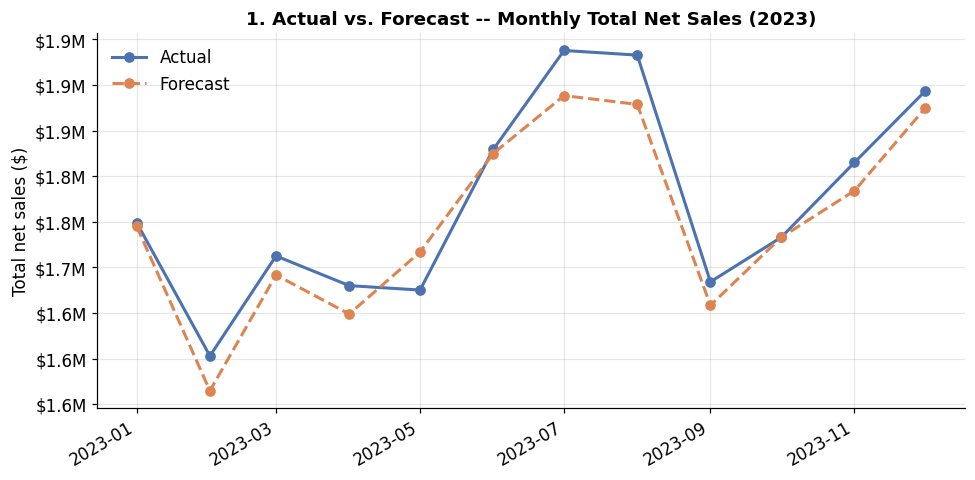

In [9]:
def plot_actual_vs_forecast(forecast_df: pd.DataFrame) -> None:
    """Monthly aggregate actual vs. forecast net_sales, 2023 test period."""
    monthly = forecast_df.groupby(forecast_df["date"].dt.to_period("M")).agg(
        actual=("net_sales", "sum"), forecast=("forecast", "sum"))
    monthly.index = monthly.index.to_timestamp()

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(monthly.index, monthly["actual"], marker="o", label="Actual", color="#4C72B0", linewidth=2)
    ax.plot(monthly.index, monthly["forecast"], marker="o", label="Forecast", color="#DD8452", linewidth=2, linestyle="--")
    ax.set_title("1. Actual vs. Forecast -- Monthly Total Net Sales (2023)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Total net sales ($)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"${y/1e6:.1f}M"))
    ax.legend(frameon=False)
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

plot_actual_vs_forecast(forecast_df)

**Business interpretation:** at the aggregate monthly level, the forecast tracks the actual trend closely across the year -- individual SKU-store-day errors partly offset each other once summed.

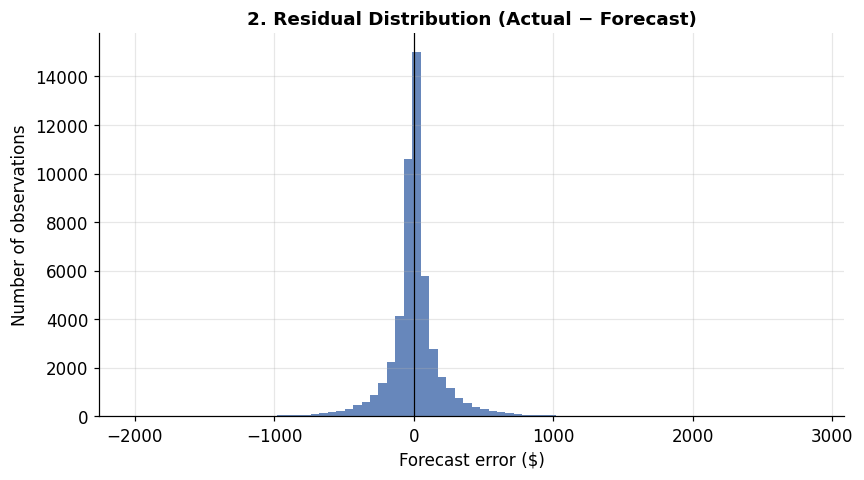

In [10]:
def plot_residual_distribution(forecast_df: pd.DataFrame) -> None:
    """Histogram of row-level forecast error (actual minus forecast)."""
    error = forecast_df["net_sales"] - forecast_df["forecast"]
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.hist(error, bins=80, color="#4C72B0", alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title("2. Residual Distribution (Actual − Forecast)", fontsize=12, fontweight="bold")
    ax.set_xlabel("Forecast error ($)")
    ax.set_ylabel("Number of observations")
    fig.tight_layout()
    plt.show()

plot_residual_distribution(forecast_df)

**Business interpretation:** errors are centered near zero with a long right tail -- most days are forecast reasonably closely, with a smaller number of much larger under-forecasts (consistent with promotion days, per Section 5).

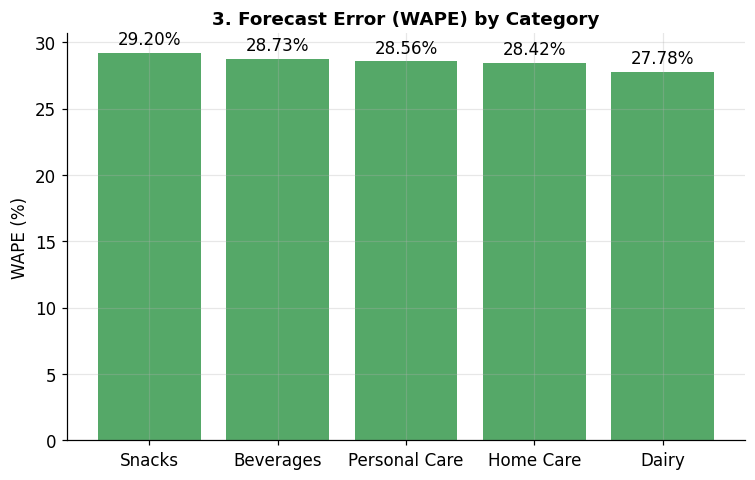

In [11]:
def plot_error_by_category(forecast_df: pd.DataFrame) -> None:
    """Bar chart of WAPE by category."""
    def _wape(g):
        e = g["net_sales"] - g["forecast"]
        return e.abs().sum() / g["net_sales"].sum() * 100
    wape_by_cat = forecast_df.groupby("category").apply(_wape, include_groups=False).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(wape_by_cat.index, wape_by_cat.values, color="#55A868")
    ax.bar_label(bars, fmt="%.2f%%", padding=3)
    ax.set_title("3. Forecast Error (WAPE) by Category", fontsize=12, fontweight="bold")
    ax.set_ylabel("WAPE (%)")
    fig.tight_layout()
    plt.show()

plot_error_by_category(forecast_df)

**Business interpretation:** WAPE is tightly clustered across categories (roughly 27.8-29.2%) -- no category is a specific outlier.

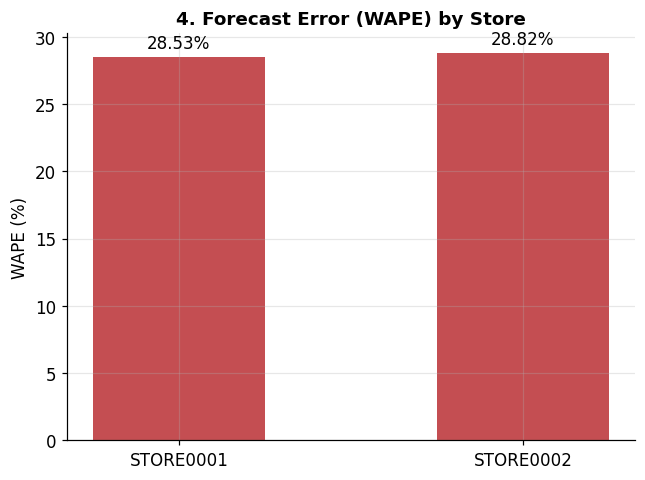

In [12]:
def plot_error_by_store(forecast_df: pd.DataFrame) -> None:
    """Bar chart of WAPE by store."""
    def _wape(g):
        e = g["net_sales"] - g["forecast"]
        return e.abs().sum() / g["net_sales"].sum() * 100
    wape_by_store = forecast_df.groupby("store_id").apply(_wape, include_groups=False)

    fig, ax = plt.subplots(figsize=(6, 4.5))
    bars = ax.bar(wape_by_store.index, wape_by_store.values, color="#C44E52", width=0.5)
    ax.bar_label(bars, fmt="%.2f%%", padding=3)
    ax.set_title("4. Forecast Error (WAPE) by Store", fontsize=12, fontweight="bold")
    ax.set_ylabel("WAPE (%)")
    fig.tight_layout()
    plt.show()

plot_error_by_store(forecast_df)

**Business interpretation:** WAPE is nearly identical between the two stores -- store is not a meaningful source of differential forecast difficulty.

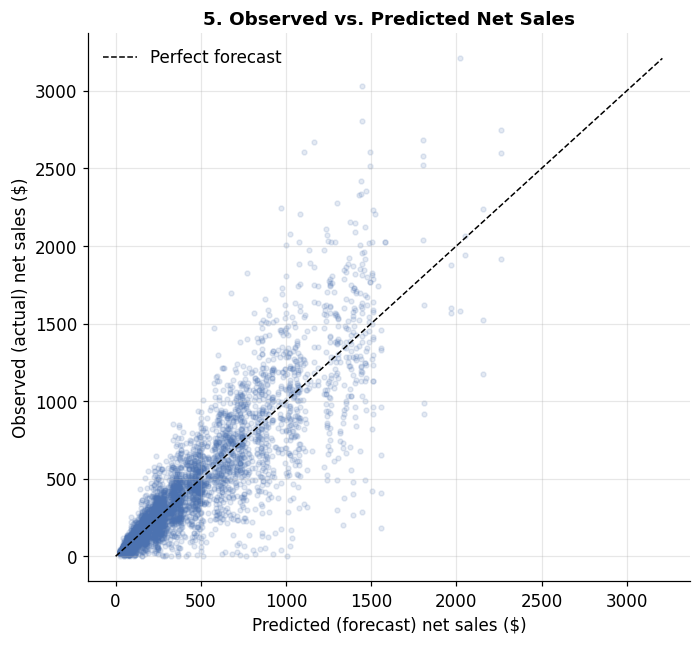

In [13]:
def plot_observed_vs_predicted(forecast_df: pd.DataFrame, sample_size: int = 5000, seed: int = 42) -> None:
    """Scatterplot of observed (actual) vs. predicted (forecast) values,
    with a 45-degree reference line -- points on the line are perfect
    forecasts; points above it are under-forecasts, below it are
    over-forecasts.
    """
    sample = forecast_df.sample(sample_size, random_state=seed)
    max_val = max(sample["net_sales"].max(), sample["forecast"].max())

    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.scatter(sample["forecast"], sample["net_sales"], alpha=0.15, s=10, color="#4C72B0")
    ax.plot([0, max_val], [0, max_val], color="black", linewidth=1, linestyle="--", label="Perfect forecast")
    ax.set_title("5. Observed vs. Predicted Net Sales", fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted (forecast) net sales ($)")
    ax.set_ylabel("Observed (actual) net sales ($)")
    ax.legend(frameon=False)
    fig.tight_layout()
    plt.show()

plot_observed_vs_predicted(forecast_df)

**Business interpretation:** most points cluster reasonably close to the 45-degree line, with a visible scatter of points well above it -- these are the under-forecast promotion days identified throughout this notebook. There is no systematic pattern of the benchmark badly over-forecasting; the visible departures run mostly in the under-forecast direction.

## Section 7 — Business Interpretation

**Which categories forecast well? Which remain difficult?** All five categories forecast similarly well -- Dairy is the easiest (27.78% WAPE) and Snacks the hardest (29.20%), but this gap is small. No category requires special handling on this evidence.

**Does promotion reduce forecast accuracy?** Yes, clearly -- WAPE jumps from 27.31% on normal days to 39.25% on promotion days, and the bias figure shows the benchmark under-forecasts promotion days by $182.63 on average. This is expected: the benchmark deliberately excludes promotional history, and this is the one place a planner should not trust it at face value.

**Does holiday reduce forecast accuracy?** No -- holidays forecast slightly better than ordinary days (26.76% vs. 28.65% WAPE), so holidays do not need special manual handling on this evidence.

**Are forecast errors operationally acceptable?** For routine, non-promotional replenishment, a WAPE around 27-29% is a reasonable starting point for a planner to sanity-check against their own judgement -- not a number to order stock from blindly, but a defensible first pass. For promotional planning, the benchmark should not be used without a manual adjustment, given the near-40% WAPE and the large positive bias on those days specifically.

## Section 8 — Should Machine Learning Be Considered?

**Not immediately, on this evidence.** The benchmark achieves 28.63% WAPE with a $4.65 overall bias, using a method any planner can compute and verify by hand. The error is not spread unexplainably across categories, stores, or holidays -- it is concentrated almost entirely in one identified, explainable segment: promotion days (39.25% WAPE, +$182.63 bias).

This matters for the ML question specifically: a machine learning model's main advantage here would need to come from better handling promotions -- and that is a targeted, well-understood gap, not a general failure of the simple approach. Modeling that one gap directly (e.g., a promotion-specific adjustment layered onto this same benchmark) is very likely to close most of the difference at a fraction of the operational complexity, data requirements, and interpretability cost of a full machine learning pipeline.

**Weighing the factors requested:**
- **MAE / RMSE / WAPE:** all in a reasonable, explainable range for non-promotional planning; the gap is isolated, not diffuse.
- **Bias:** small and explainable overall; large only on the specific, known promotion segment.
- **Interpretability:** currently very high (a spreadsheet-computable average) -- a machine learning model would lose this without yet having demonstrated it earns the trade.
- **Operational complexity:** currently minimal; ML would add real infrastructure, monitoring, and retraining overhead that has not yet been justified by an unexplained accuracy gap.

**Evidence is not yet sufficient to justify ML** -- what would justify it is a demonstrated failure of a promotion-adjusted version of this same simple benchmark, which has not been built or tested here.

## Section 9 — Evidence Register

| Finding | Evidence | Confidence | Business Implication |
|---|---|---|---|
| The benchmark achieves 28.63% WAPE out-of-sample | Computed on a genuine 2023 holdout, never seen during construction | Strong | Reasonable starting point for routine, non-promotional planning |
| Forecast error is concentrated in promotion days | WAPE 39.25% (promotion) vs. 27.31% (non-promotion); bias +$182.63 on promotion days | Strong | Promotion days require manual adjustment; non-promotion days do not |
| Store and category do not meaningfully affect forecast difficulty | WAPE range 28.53-28.82% (store), 27.78-29.20% (category) | Strong | No segment-specific process is required for store or category |
| Holidays do not reduce forecast accuracy | WAPE 26.76% (holiday) vs. 28.65% (non-holiday) | Strong | No special holiday handling required |
| Machine learning is not yet justified | Error is concentrated in one explainable, targetable segment rather than spread unexplainably | Moderate | Prioritize a promotion-specific adjustment to this same benchmark before considering ML |
| Whether this benchmark beats current planner judgement | No historical planner forecast data exists for comparison | Insufficient Data | Cannot be claimed either way without collecting that comparison data |

## Section 10 — Notebook Summary

**What this notebook established:** a Seasonal Historical Average forecasting benchmark, trained on 2021-2022 and evaluated out-of-sample on 2023, achieving 28.63% WAPE overall, with forecast error concentrated specifically and explainably in promotion days rather than spread across stores, categories, or holidays. On this evidence, machine learning is not yet justified -- a targeted promotion adjustment to this same simple benchmark is the more evidence-supported next step.

**What this notebook did NOT establish:** whether this benchmark is more or less accurate than current planner judgement (no historical planner forecast data exists for that comparison); any monetary value of forecast improvement; any causal claim about why promotions lift sales.

**Notebook 04 evaluates forecast quality only.** Promotion effectiveness, weather, seasonality, and business drivers have already been established in Notebook 03 and are not re-tested here.

## Section 11 — Transition to Notebook 05

Notebook 05 will combine Notebook 03 (Hypothesis Testing) and Notebook 04 (Forecast Benchmark) to produce practical business recommendations -- using only the statistically supported findings and the forecast evidence established in these two notebooks, with no new testing or forecasting performed there.